In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

from computer_computer.io import (
    read_courses_tsv,
    read_preferences_tsv,
    read_students_tsv,
    read_teachers_tsv,
)
from computer_computer.solver import ComputerComputerSolver

In [2]:
data_dir = Path("tests/data")

student_data = pd.read_csv(data_dir / "students.tsv", delimiter="\t")
teacher_data = pd.read_csv(data_dir / "teachers.tsv", delimiter="\t")
course_data = pd.read_csv(data_dir / "courses.tsv", delimiter="\t")
preference_data = pd.read_csv(data_dir / "preferences.tsv", delimiter="\t")

students = read_students_tsv(data_dir / "students.tsv")
teachers = read_teachers_tsv(data_dir / "teachers.tsv")
courses = read_courses_tsv(data_dir / "courses.tsv", teachers=teachers)
first_choices, second_choices = read_preferences_tsv(
    data_dir / "preferences.tsv", students=students, courses=courses
)

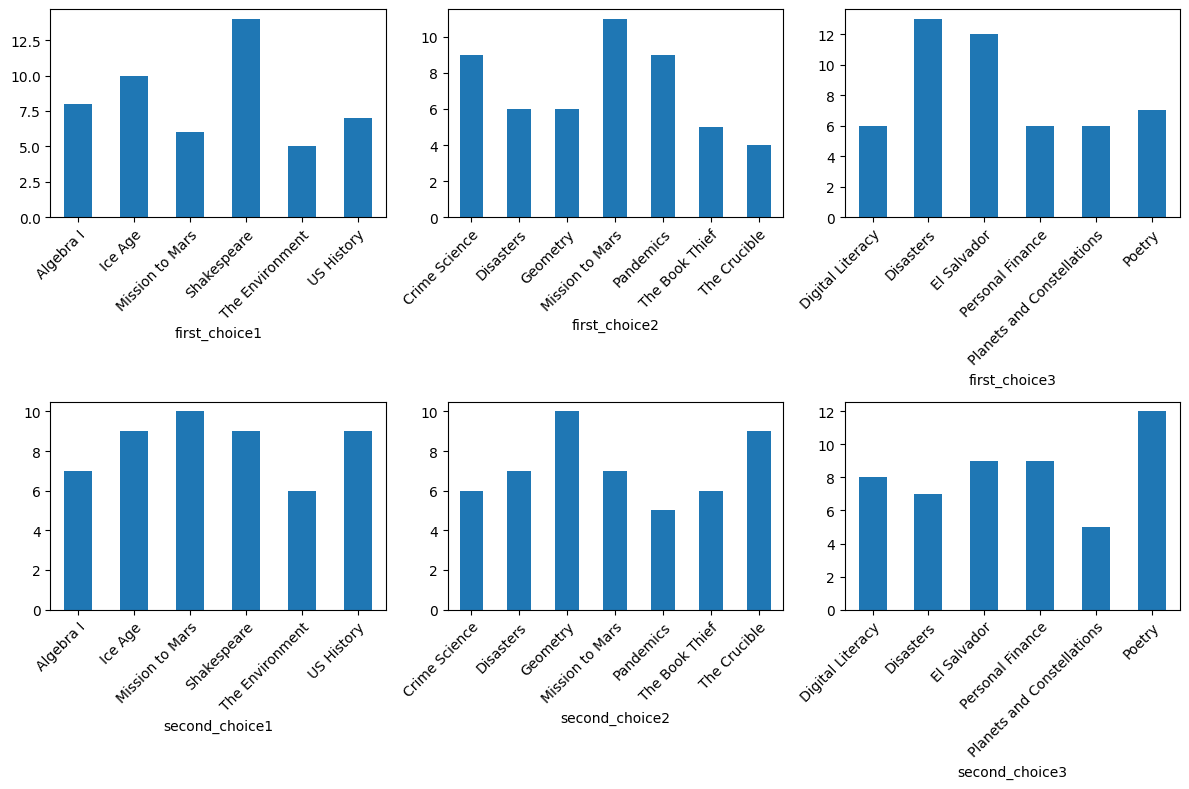

In [3]:
fig, [(ax1, ax2, ax3), (ax4, ax5, ax6)] = plt.subplots(2, 3, figsize=(12, 8), layout="tight")
preference_data["first_choice1"].value_counts().sort_index().plot.bar(ax=ax1, rot=45)
preference_data["first_choice2"].value_counts().sort_index().plot.bar(ax=ax2, rot=45)
preference_data["first_choice3"].value_counts().sort_index().plot.bar(ax=ax3, rot=45)
preference_data["second_choice1"].value_counts().sort_index().plot.bar(ax=ax4, rot=45)
preference_data["second_choice2"].value_counts().sort_index().plot.bar(ax=ax5, rot=45)
preference_data["second_choice3"].value_counts().sort_index().plot.bar(ax=ax6, rot=45)
for ax in [ax1, ax2, ax3, ax4, ax5, ax6]:
    ax.set_xticklabels(ax.get_xticklabels(), ha="right", rotation_mode="anchor")

In [4]:
solver = ComputerComputerSolver(students, courses)
assignments = solver.get_optimal_course_assignments(first_choices, second_choices, disp=True)
period1 = [(course, students) for course, students in assignments.items() if course.period == 1]
period2 = [(course, students) for course, students in assignments.items() if course.period == 2]
period3 = [(course, students) for course, students in assignments.items() if course.period == 3]
period1.sort(key=lambda pair: pair[0].title)
period2.sort(key=lambda pair: pair[0].title)
period3.sort(key=lambda pair: pair[0].title)
assigned_first_choice = [
    (course, len([student for student in students if course in first_choices[student]]))
    for course, students in assignments.items()
]
assigned_second_choice = [
    (course, len([student for student in students if course in second_choices[student]]))
    for course, students in assignments.items()
]
assigned_first_choice.sort(key=lambda pair: pair[0].title)
assigned_second_choice.sort(key=lambda pair: pair[0].title)

Running HiGHS 1.8.0 (git hash: 222cce7): Copyright (c) 2024 HiGHS under MIT licence terms
Coefficient ranges:
  Matrix [1e+00, 2e+00]
  Cost   [1e+00, 2e+00]
  Bound  [1e+00, 1e+00]
  RHS    [1e+00, 2e+01]
Presolving model
236 rows, 988 cols, 2975 nonzeros  0s
217 rows, 988 cols, 2025 nonzeros  0s

Solving MIP model with:
   217 rows
   988 cols (950 binary, 0 integer, 25 implied int., 13 continuous)
   2025 nonzeros
MIP-Timing:      0.0071 - starting analytic centre calculation

Src: B => Branching; C => Central rounding; F => Feasibility pump; H => Heuristic; L => Sub-MIP;
     P => Empty MIP; R => Randomized rounding; S => Solve LP; T => Evaluate node; U => Unbounded;
     z => Trivial zero; l => Trivial lower; u => Trivial upper; p => Trivial point

        Nodes      |    B&B Tree     |            Objective Bounds              |  Dynamic Constraints |       Work      
Src  Proc. InQueue |  Leaves   Expl. | BestBound       BestSol              Gap |   Cuts   InLp Confl. | LpIters  

/var/folders/41/3svjv1fs5pdbcb0v1sv86zhr0000gn/T/ipykernel_37995/783119086.py:69: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")
/var/folders/41/3svjv1fs5pdbcb0v1sv86zhr0000gn/T/ipykernel_37995/783119086.py:69: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")
/var/folders/41/3svjv1fs5pdbcb0v1sv86zhr0000gn/T/ipykernel_37995/783119086.py:69: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")
/var/folders/41/3svjv1fs5pdbcb0v1sv86zhr0000gn/T/ipykernel_37995/783119086.py:69: UserWarning:

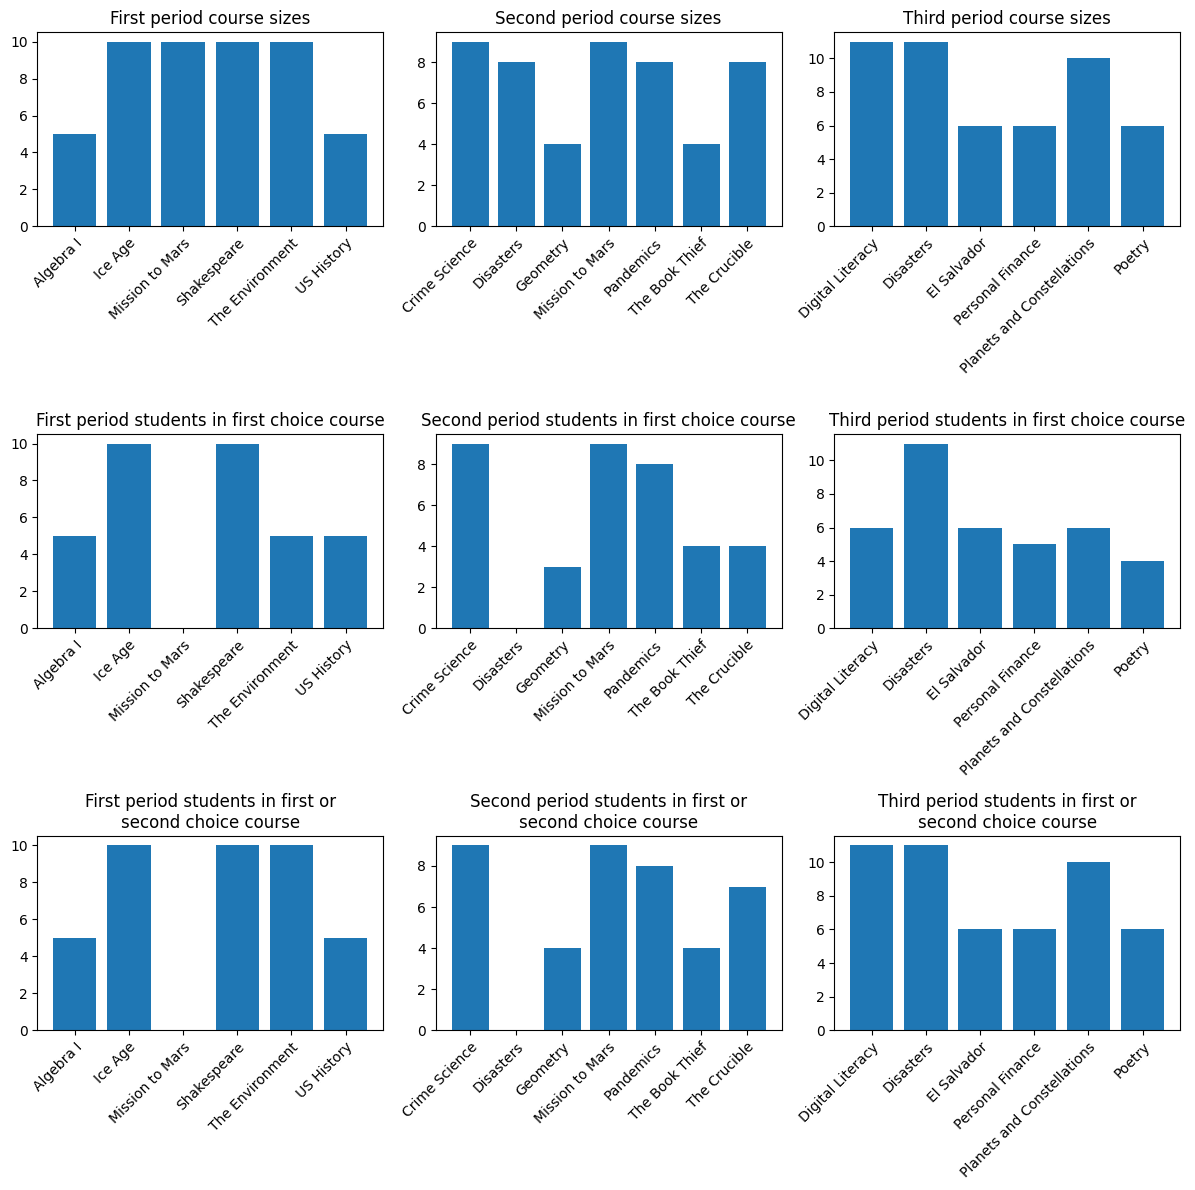

In [5]:
fig, [(ax1, ax2, ax3), (ax4, ax5, ax6), (ax7, ax8, ax9)] = plt.subplots(
    3, 3, figsize=(12, 12), layout="tight"
)
ax1.bar(
    [course.title for course, students in period1], [len(students) for course, students in period1]
)
ax1.set_title("First period course sizes")
ax4.bar(
    [course.title for course, n_students in assigned_first_choice if course.period == 1],
    [n_students for course, n_students in assigned_first_choice if course.period == 1],
)
ax4.set_title("First period students in first choice course")
ax7.bar(
    [course.title for course, n_students in assigned_first_choice if course.period == 1],
    [
        n_students_first + n_students_second
        for (course1, n_students_first), (course2, n_students_second) in zip(
            assigned_first_choice, assigned_second_choice
        )
        if course1.period == 1
    ],
)
ax7.set_title("First period students in first or\nsecond choice course")

ax2.bar(
    [course.title for course, students in period2], [len(students) for course, students in period2]
)
ax2.set_title("Second period course sizes")
ax5.bar(
    [course.title for course, n_students in assigned_first_choice if course.period == 2],
    [n_students for course, n_students in assigned_first_choice if course.period == 2],
)
ax5.set_title("Second period students in first choice course")
ax8.bar(
    [course.title for course, n_students in assigned_first_choice if course.period == 2],
    [
        n_students_first + n_students_second
        for (course1, n_students_first), (course2, n_students_second) in zip(
            assigned_first_choice, assigned_second_choice
        )
        if course1.period == 2
    ],
)
ax8.set_title("Second period students in first or\nsecond choice course")


ax3.bar(
    [course.title for course, students in period3], [len(students) for course, students in period3]
)
ax3.set_title("Third period course sizes")
ax6.bar(
    [course.title for course, n_students in assigned_first_choice if course.period == 3],
    [n_students for course, n_students in assigned_first_choice if course.period == 3],
)
ax9.bar(
    [course.title for course, n_students in assigned_first_choice if course.period == 3],
    [
        n_students_first + n_students_second
        for (course1, n_students_first), (course2, n_students_second) in zip(
            assigned_first_choice, assigned_second_choice
        )
        if course1.period == 3
    ],
)
ax9.set_title("Third period students in first or\nsecond choice course")

ax6.set_title("Third period students in first choice course")
for ax in [ax1, ax2, ax3, ax4, ax5, ax6, ax7, ax8, ax9]:
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")